# UTS Praktikum Machine Learning
## Klasifikasi Kondisi Pertumbuhan Tanaman (Agro-Environmental Classification)

Notebook ini berisi seluruh proses pelatihan model machine learning untuk mengklasifikasikan apakah suatu tanaman dapat tumbuh pada kondisi tanah tertentu (`failure_flag = 0` artinya tanaman bisa tumbuh, `failure_flag = 1` artinya gagal tumbuh).

**Alur kerja:**
1. Import library
2. Load dataset
3. Exploratory Data Analysis (EDA)
4. Preprocessing
5. Penanganan Imbalanced Dataset
6. Pelatihan Model & Ensemble Learning
7. Hyperparameter Tuning & Cross-Validation
8. Evaluasi Model
9. Simpan Model

## 1. Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from imblearn.over_sampling import SMOTE

## 2. Load Dataset

In [2]:
# Load dataset
df = pd.read_csv('../dataset/agro_environmental_dataset.csv')

print(f'Shape dataset: {df.shape}')
print(f'Jumlah baris: {df.shape[0]:,}')
print(f'Jumlah kolom: {df.shape[1]}')
df.head()

Shape dataset: (543210, 25)
Jumlah baris: 543,210
Jumlah kolom: 25


,location_id,soil_type,bulk_density,organic_matter_pct,cation_exchange_capacity,salinity_ec,buffering_capacity,soil_moisture_pct,moisture_limit_dry,moisture_limit_wet,...,soil_ph,ph_stress_flag,nitrogen_ppm,phosphorus_ppm,potassium_ppm,nutrient_balance,plant_category,suitability_score,stress_level,failure_flag
0,L00000,Clayey,1.1,4.0,30,0.5,0.9,5.17,25,52,...,6.48,0,100.1,50.8,121.3,excessive,vegetable,0.677,1,0
1,L00001,Alluvial,1.3,3.8,20,0.4,0.7,26.28,16,45,...,6.43,0,133.8,54.9,151.6,optimal,vegetable,0.871,0,0
2,L00002,Chalky,1.5,2.0,8,0.3,0.4,44.90,12,35,...,5.01,1,84.5,83.6,83.6,deficient,vegetable,0.000,2,1
3,L00003,Silty,1.4,3.0,18,0.4,0.6,27.05,18,42,...,5.41,1,168.2,30.5,220.0,deficient,cereal,0.510,1,0
4,L00004,Loamy,1.3,3.5,15,0.3,0.7,36.56,15,40,...,6.73,0,98.9,63.4,88.9,optimal,vegetable,1.000,0,0


## 3. Exploratory Data Analysis (EDA)

Pada tahap ini kita akan memahami karakteristik dataset secara mendalam, meliputi:
- Informasi umum dataset
- Distribusi data
- Penanganan duplikasi
- Penanganan missing values
- Analisis korelasi
- Distribusi target (imbalanced check)

In [3]:
# Informasi umum dataset
print('=== INFO DATASET ===')
df.info()

=== INFO DATASET ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 543210 entries, 0 to 543209
Data columns (total 25 columns):
 #   Column                    Non-Null Count   Dtype  
---  ------                    --------------   -----  
 0   location_id               543210 non-null  object 
 1   soil_type                 543210 non-null  object 
 2   bulk_density              543210 non-null  float64
 3   organic_matter_pct        543210 non-null  float64
 4   cation_exchange_capacity  543210 non-null  int64  
 5   salinity_ec               543210 non-null  float64
 6   buffering_capacity        543210 non-null  float64
 7   soil_moisture_pct         543210 non-null  float64
 8   moisture_limit_dry        543210 non-null  int64  
 9   moisture_limit_wet        543210 non-null  int64  
 10  moisture_regime           543210 non-null  object 
 11  soil_temp_c               543210 non-null  float64
 12  air_temp_c                543210 non-null  float64
 13  thermal_regime         

In [4]:
# Statistik deskriptif fitur numerik
print('=== STATISTIK DESKRIPTIF ===')
df.describe()

=== STATISTIK DESKRIPTIF ===


,bulk_density,organic_matter_pct,cation_exchange_capacity,salinity_ec,buffering_capacity,soil_moisture_pct,moisture_limit_dry,moisture_limit_wet,soil_temp_c,air_temp_c,light_intensity_par,soil_ph,ph_stress_flag,nitrogen_ppm,phosphorus_ppm,potassium_ppm,suitability_score,stress_level,failure_flag
count,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000,543210.000000
mean,1.319365,4.000303,17.212248,0.673847,0.610260,34.977238,16.945798,42.566326,25.003662,28.007091,699.682397,6.499156,0.206417,100.369819,50.593494,110.290247,0.613343,0.914698,0.162147
std,0.243070,4.278072,10.367455,0.986025,0.198579,11.927853,6.615230,9.681918,4.991071,5.379043,288.943448,0.892323,0.404734,39.138892,23.827609,43.769883,0.246283,0.743454,0.368586
min,0.700000,1.200000,5.000000,0.200000,0.300000,5.000000,8.000000,28.000000,10.000000,7.000000,200.000000,4.000000,0.000000,20.000000,10.000000,20.000000,0.000000,0.000000,0.000000
25%,1.300000,1.800000,8.000000,0.300000,0.400000,26.870000,12.000000,38.000000,21.600000,24.400000,450.000000,5.890000,0.000000,73.000000,33.100000,79.700000,0.457000,0.000000,0.000000
50%,1.300000,3.500000,15.000000,0.400000,0.700000,34.970000,16.000000,42.000000,25.000000,28.000000,699.000000,6.500000,0.000000,100.000000,50.100000,110.000000,0.628000,1.000000,0.000000
75%,1.500000,3.800000,20.000000,0.500000,0.700000,43.070000,22.000000,45.000000,28.400000,31.600000,949.000000,7.110000,0.000000,127.000000,66.900000,140.300000,0.784000,1.000000,0.000000
max,1.600000,18.000000,40.000000,4.000000,0.900000,70.000000,30.000000,65.000000,40.000000,49.600000,1200.000000,8.800000,1.000000,220.000000,159.000000,220.000000,1.000000,2.000000,1.000000


In [5]:
# Cek missing values
print('=== MISSING VALUES ===')
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct})
print(missing_df[missing_df['Missing Count'] > 0])
print(f'\nTotal missing values: {df.isnull().sum().sum()}')

=== MISSING VALUES ===
Empty DataFrame
Columns: [Missing Count, Missing (%)]
Index: []

Total missing values: 0


In [6]:
# Cek dan hapus duplikasi
print(f'Jumlah baris duplikat: {df.duplicated().sum()}')
df = df.drop_duplicates()
print(f'Shape setelah hapus duplikat: {df.shape}')

Jumlah baris duplikat: 0
Shape setelah hapus duplikat: (543210, 25)


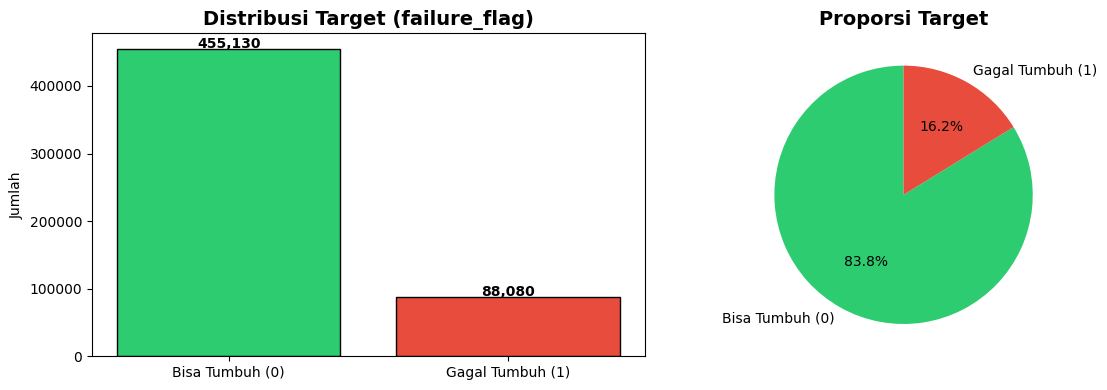


Distribusi target:
failure_flag
0    455130
1     88080
Name: count, dtype: int64

Rasio imbalanced: 5.17:1
=> Dataset IMBALANCED, perlu penanganan khusus!


In [7]:
# Distribusi target variable
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = df['failure_flag'].value_counts()
target_labels = ['Bisa Tumbuh (0)', 'Gagal Tumbuh (1)']

axes[0].bar(target_labels, target_counts.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_title('Distribusi Target (failure_flag)', fontsize=14, fontweight='bold')
axes[0].set_ylabel('Jumlah')
for i, v in enumerate(target_counts.values):
    axes[0].text(i, v + 1000, f'{v:,}', ha='center', fontweight='bold')

axes[1].pie(target_counts.values, labels=target_labels, autopct='%1.1f%%',
            colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[1].set_title('Proporsi Target', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()

print(f'\nDistribusi target:')
print(target_counts)
print(f'\nRasio imbalanced: {target_counts[0]/target_counts[1]:.2f}:1')
print('=> Dataset IMBALANCED, perlu penanganan khusus!')

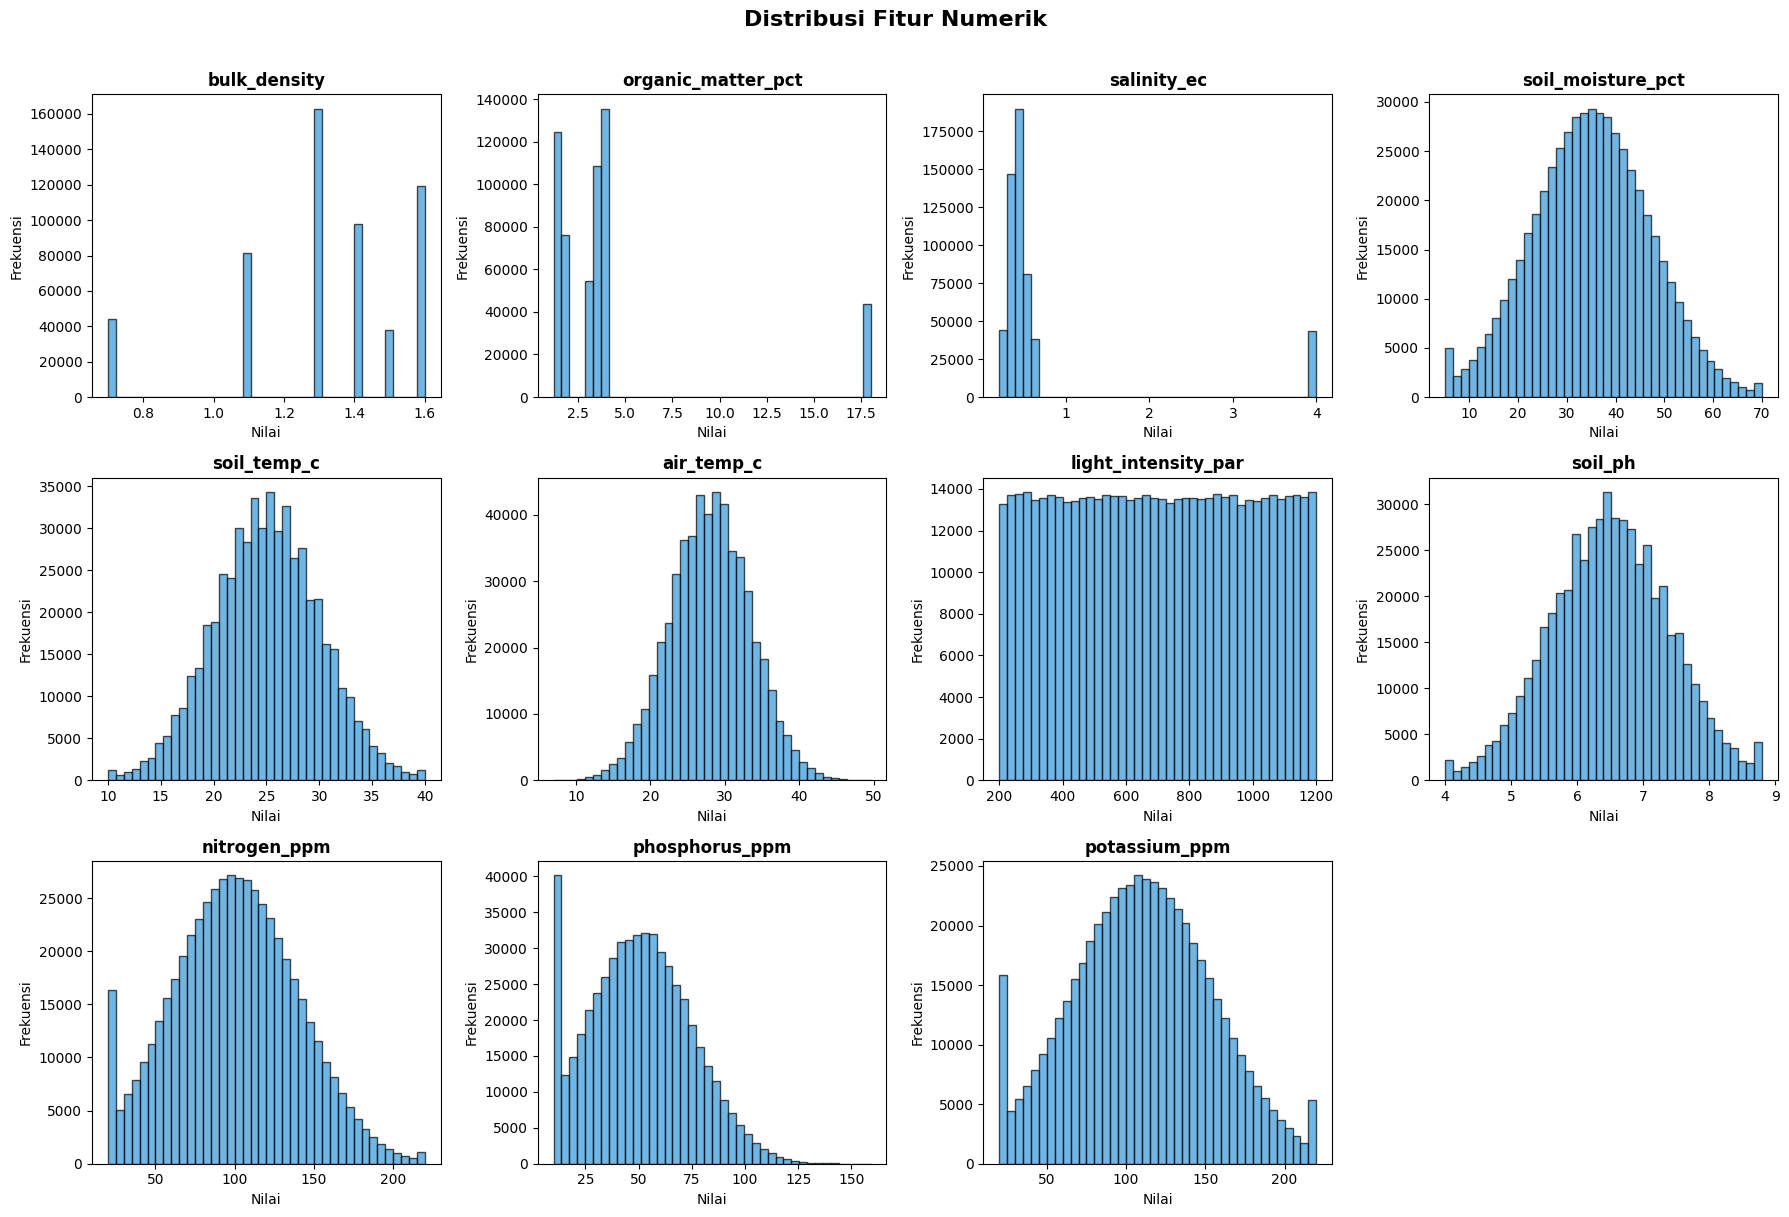

In [8]:
# Distribusi fitur numerik
numeric_cols = ['bulk_density', 'organic_matter_pct', 'salinity_ec', 'soil_moisture_pct',
                'soil_temp_c', 'air_temp_c', 'light_intensity_par', 'soil_ph',
                'nitrogen_ppm', 'phosphorus_ppm', 'potassium_ppm']

fig, axes = plt.subplots(3, 4, figsize=(18, 12))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=40, color='#3498db', edgecolor='black', alpha=0.7)
    axes[i].set_title(col, fontweight='bold')
    axes[i].set_xlabel('Nilai')
    axes[i].set_ylabel('Frekuensi')

# Sembunyikan subplot yang tidak terpakai
for j in range(len(numeric_cols), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Distribusi Fitur Numerik', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.show()

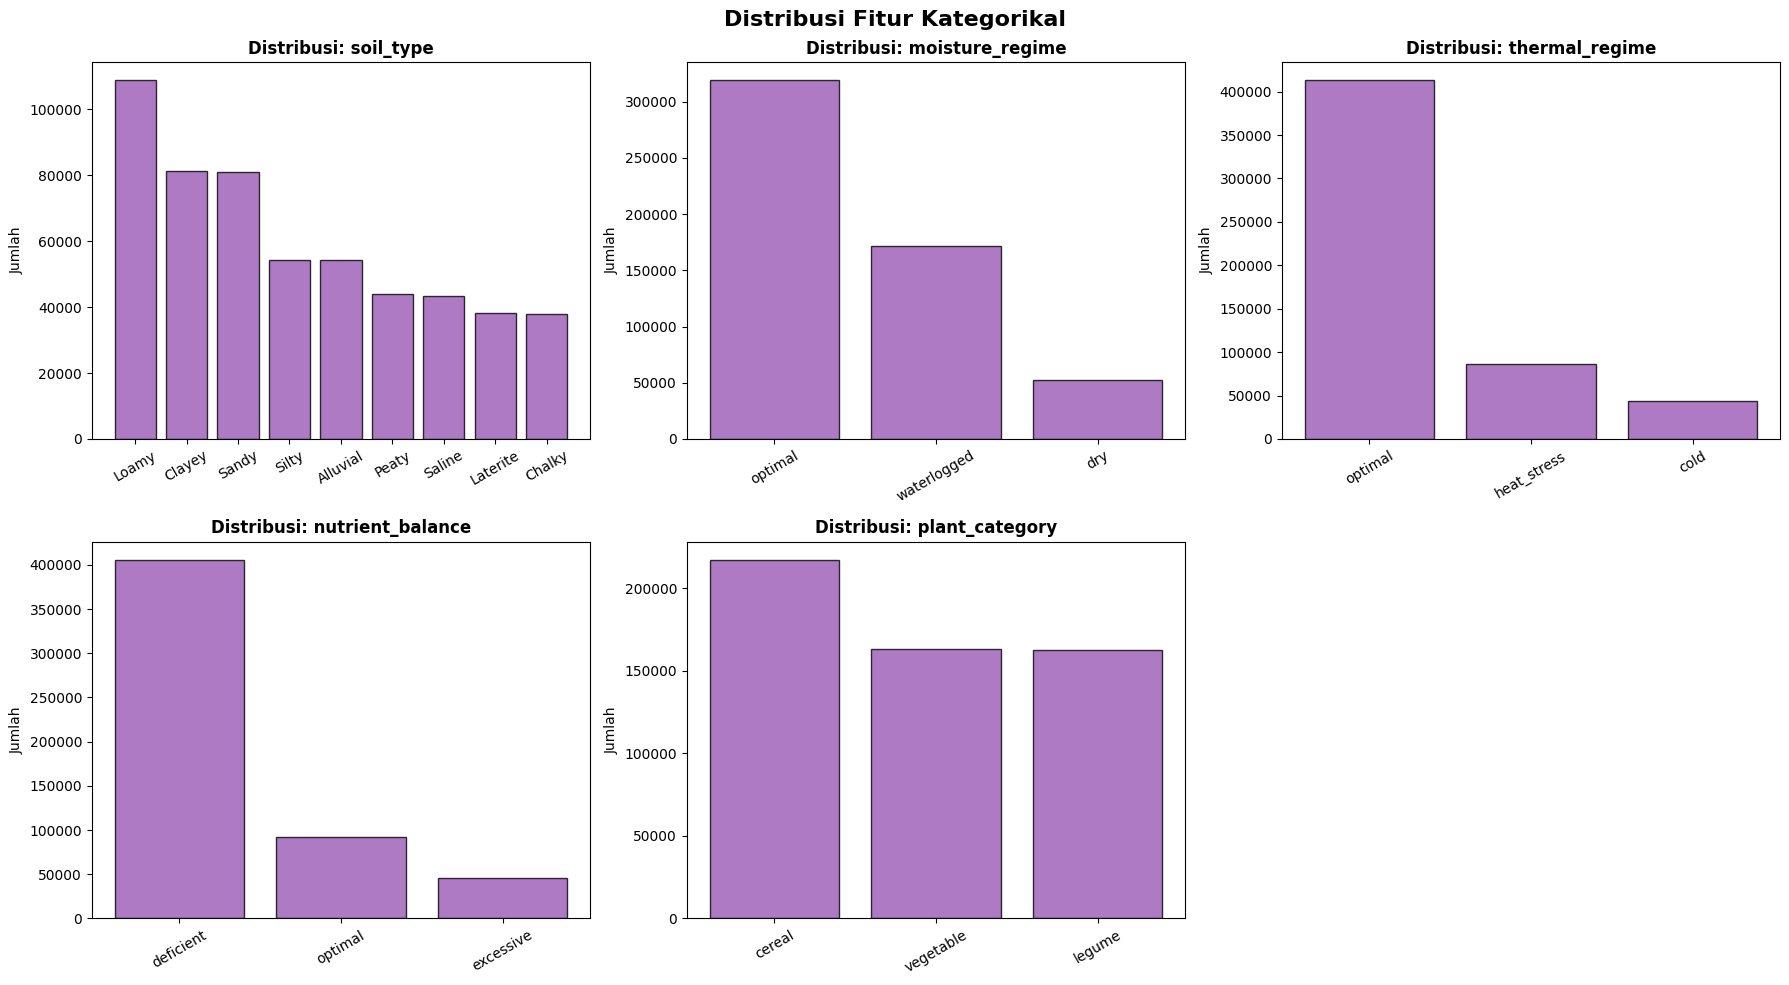

In [9]:
# Distribusi fitur kategorikal
cat_cols = ['soil_type', 'moisture_regime', 'thermal_regime', 'nutrient_balance', 'plant_category']

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(cat_cols):
    counts = df[col].value_counts()
    axes[i].bar(counts.index, counts.values, color='#9b59b6', edgecolor='black', alpha=0.8)
    axes[i].set_title(f'Distribusi: {col}', fontweight='bold')
    axes[i].set_ylabel('Jumlah')
    axes[i].tick_params(axis='x', rotation=30)

axes[5].set_visible(False)
plt.suptitle('Distribusi Fitur Kategorikal', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

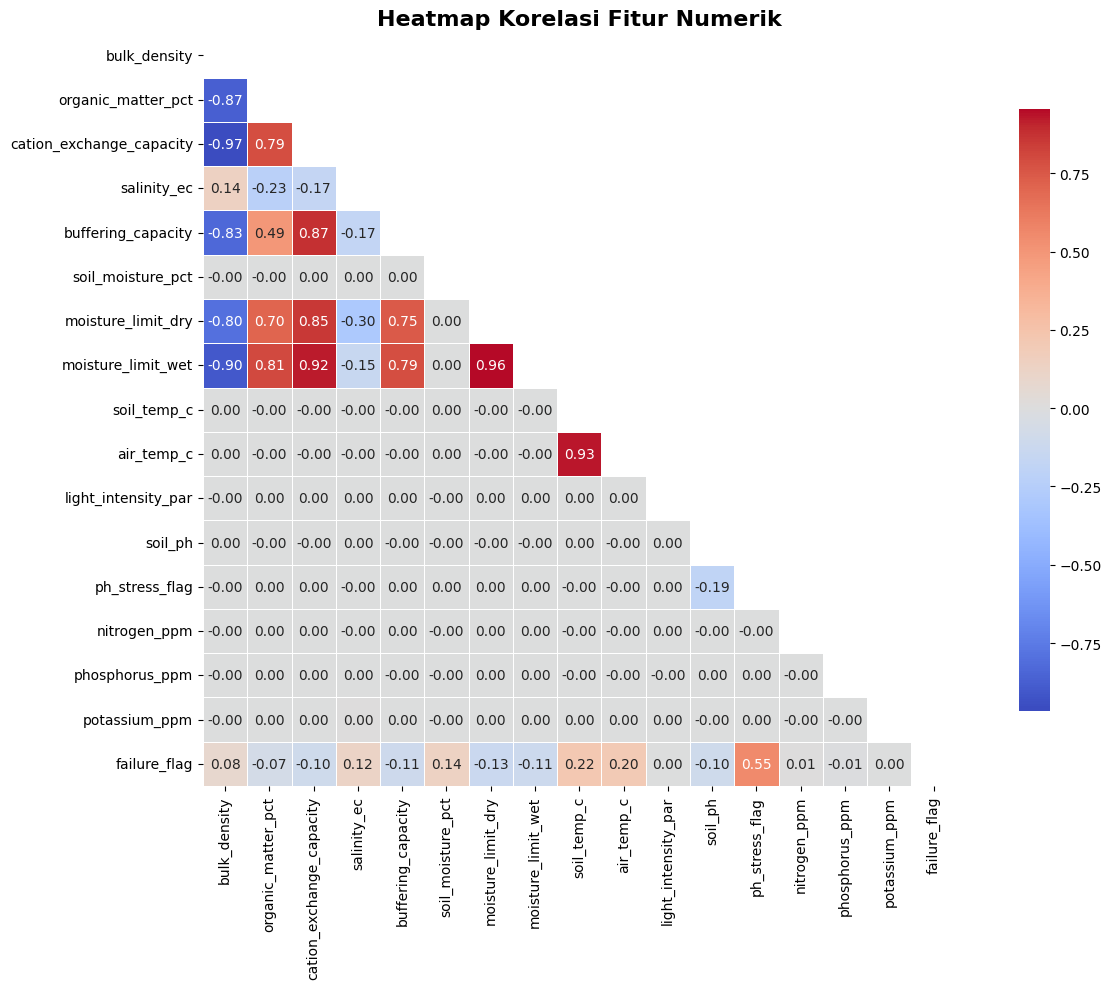

In [10]:
# Heatmap Korelasi Fitur Numerik
# Kita drop kolom yang bukan fitur prediksi dulu
drop_cols = ['location_id', 'suitability_score', 'stress_level']
df_corr = df.drop(columns=drop_cols)

numeric_for_corr = df_corr.select_dtypes(include='number').columns.tolist()

plt.figure(figsize=(14, 10))
corr_matrix = df_corr[numeric_for_corr].corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix,
    mask=mask,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    center=0,
    linewidths=0.5,
    square=True,
    cbar_kws={'shrink': 0.8}
)
plt.title('Heatmap Korelasi Fitur Numerik', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

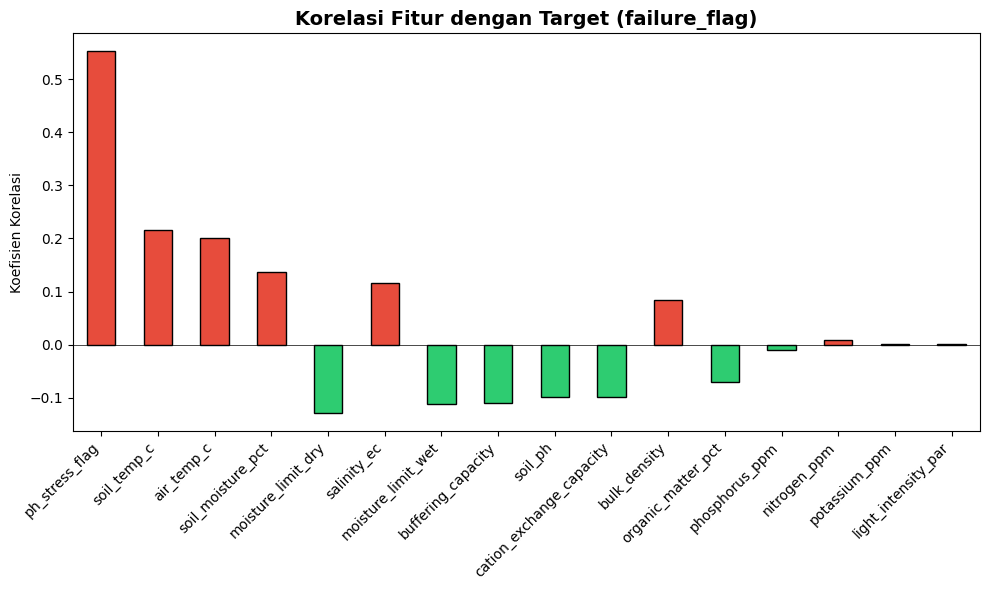

Korelasi fitur dengan target:
ph_stress_flag              0.552076
soil_temp_c                 0.216402
air_temp_c                  0.201002
soil_moisture_pct           0.137044
moisture_limit_dry         -0.127956
salinity_ec                 0.116752
moisture_limit_wet         -0.111998
buffering_capacity         -0.108961
soil_ph                    -0.099133
cation_exchange_capacity   -0.097666
bulk_density                0.084758
organic_matter_pct         -0.069632
phosphorus_ppm             -0.009802
nitrogen_ppm                0.009500
potassium_ppm               0.001123
light_intensity_par         0.000776
Name: failure_flag, dtype: float64


In [11]:
# Analisis korelasi terhadap target
corr_with_target = df_corr[numeric_for_corr].corr()['failure_flag'].drop('failure_flag').sort_values(key=abs, ascending=False)

plt.figure(figsize=(10, 6))
colors = ['#e74c3c' if x > 0 else '#2ecc71' for x in corr_with_target.values]
corr_with_target.plot(kind='bar', color=colors, edgecolor='black')
plt.title('Korelasi Fitur dengan Target (failure_flag)', fontsize=14, fontweight='bold')
plt.ylabel('Koefisien Korelasi')
plt.axhline(y=0, color='black', linestyle='-', linewidth=0.5)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print('Korelasi fitur dengan target:')
print(corr_with_target)

## 4. Preprocessing

Langkah preprocessing:
1. Drop kolom yang tidak relevan (`location_id`, `suitability_score`, `stress_level`)
   - `location_id`: hanya ID, tidak memiliki makna prediktif
   - `suitability_score` & `stress_level`: merupakan variabel turunan yang langsung terkait dengan target, sehingga jika disertakan akan menyebabkan **data leakage**
2. Pisahkan fitur (X) dan target (y)
3. Encoding fitur kategorikal
4. Scaling fitur numerik

In [12]:
# Drop kolom tidak relevan
DROP_COLS = ['location_id', 'suitability_score', 'stress_level']
df_clean = df.drop(columns=DROP_COLS)

# Pisahkan fitur dan target
X = df_clean.drop(columns=['failure_flag'])
y = df_clean['failure_flag']

print(f'Shape X: {X.shape}')
print(f'Shape y: {y.shape}')
print(f'\nKolom fitur ({len(X.columns)}):')
print(X.columns.tolist())

Shape X: (543210, 21)
Shape y: (543210,)

Kolom fitur (21):
['soil_type', 'bulk_density', 'organic_matter_pct', 'cation_exchange_capacity', 'salinity_ec', 'buffering_capacity', 'soil_moisture_pct', 'moisture_limit_dry', 'moisture_limit_wet', 'moisture_regime', 'soil_temp_c', 'air_temp_c', 'thermal_regime', 'light_intensity_par', 'soil_ph', 'ph_stress_flag', 'nitrogen_ppm', 'phosphorus_ppm', 'potassium_ppm', 'nutrient_balance', 'plant_category']


In [13]:
# Definisikan kolom numerik dan kategorikal
NUMERIC_FEATURES = [
    'bulk_density', 'organic_matter_pct', 'cation_exchange_capacity',
    'salinity_ec', 'buffering_capacity', 'soil_moisture_pct',
    'moisture_limit_dry', 'moisture_limit_wet', 'soil_temp_c',
    'air_temp_c', 'light_intensity_par', 'soil_ph',
    'ph_stress_flag', 'nitrogen_ppm', 'phosphorus_ppm', 'potassium_ppm'
]

CATEGORICAL_FEATURES = [
    'soil_type', 'moisture_regime', 'thermal_regime',
    'nutrient_balance', 'plant_category'
]

print('Fitur Numerik:')
for f in NUMERIC_FEATURES:
    print(f'  - {f}')

print('\nFitur Kategorikal:')
for f in CATEGORICAL_FEATURES:
    print(f'  - {f}')

Fitur Numerik:
  - bulk_density
  - organic_matter_pct
  - cation_exchange_capacity
  - salinity_ec
  - buffering_capacity
  - soil_moisture_pct
  - moisture_limit_dry
  - moisture_limit_wet
  - soil_temp_c
  - air_temp_c
  - light_intensity_par
  - soil_ph
  - ph_stress_flag
  - nitrogen_ppm
  - phosphorus_ppm
  - potassium_ppm

Fitur Kategorikal:
  - soil_type
  - moisture_regime
  - thermal_regime
  - nutrient_balance
  - plant_category


In [14]:
# Train-test split (stratified agar distribusi target seimbang)
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print(f'Train size: {X_train.shape[0]:,}')
print(f'Test size:  {X_test.shape[0]:,}')
print(f'\nDistribusi train: {y_train.value_counts().to_dict()}')
print(f'Distribusi test:  {y_test.value_counts().to_dict()}')

Train size: 434,568
Test size:  108,642

Distribusi train: {0: 364104, 1: 70464}
Distribusi test:  {0: 91026, 1: 17616}


In [15]:
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Bangun preprocessing pipeline
numeric_transformer = Pipeline(steps=[
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline(steps=[
    ('onehot', OneHotEncoder(handle_unknown='ignore', sparse_output=False))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, NUMERIC_FEATURES),
        ('cat', categorical_transformer, CATEGORICAL_FEATURES)
    ]
)

print('Preprocessing pipeline berhasil dibuat!')

Preprocessing pipeline berhasil dibuat!


## 5. Penanganan Imbalanced Dataset

Dataset kita imbalanced dengan rasio sekitar 5:1 (bisa tumbuh vs gagal tumbuh). Kita akan menggunakan dua strategi:
1. **SMOTE** (Synthetic Minority Over-sampling Technique) untuk oversampling kelas minoritas
2. **class_weight='balanced'** pada model sebagai fallback

In [19]:
# Preprocessing data terlebih dahulu sebelum SMOTE
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f'Shape setelah preprocessing - Train: {X_train_preprocessed.shape}')
print(f'Shape setelah preprocessing - Test: {X_test_preprocessed.shape}')

Shape setelah preprocessing - Train: (434568, 37)
Shape setelah preprocessing - Test: (108642, 37)


In [20]:
# Terapkan SMOTE pada data train saja
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_res, y_train_res = smote.fit_resample(X_train_processed, y_train)

print("Distribusi sebelum SMOTE:", y_train.value_counts().to_dict())
print("Distribusi setelah SMOTE:", y_train_res.value_counts().to_dict())
print("Shape setelah SMOTE:", X_train_res.shape)

Distribusi sebelum SMOTE: {0: 364104, 1: 70464}
Distribusi setelah SMOTE: {0: 364104, 1: 364104}
Shape setelah SMOTE: (728208, 37)


## 6. Pelatihan Model & Ensemble Learning

Kita akan melatih beberapa model dan membandingkan performanya:
1. **Random Forest** — Bagging ensemble dari decision tree
2. **Gradient Boosting** — Boosting ensemble
3. **Stacking Classifier** — Meta-ensemble yang menggabungkan Random Forest + Gradient Boosting dengan Logistic Regression sebagai meta-learner

Stacking dipilih sebagai model akhir karena menggabungkan kekuatan kedua metode (bagging + boosting) sehingga menghasilkan prediksi yang lebih robust.

In [22]:
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, f1_score

base_models = {
    'Random Forest': RandomForestClassifier(
        n_estimators=50,          # dikurangi biar cepat
        random_state=42,
        class_weight='balanced',
        n_jobs=2                  # jangan full CPU
    ),
    
    'Decision Tree': DecisionTreeClassifier(
        random_state=42,
        max_depth=10             # biar tidak overkill
    )
}

results = {}

for name, model in base_models.items():
    print(f"\nTraining {name}...")

    model.fit(X_train_res, y_train_res)
    
    y_pred = model.predict(X_test_preprocessed)
    
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred)
    
    results[name] = {
        'accuracy': acc,
        'f1': f1,
        'model': model
    }
    
    print(f'{name} => Accuracy: {acc:.4f}, F1-Score: {f1:.4f}')

print('\nPerbandingan model dasar selesai!')


Training Random Forest...
Random Forest => Accuracy: 0.9857, F1-Score: 0.9557

Training Decision Tree...
Decision Tree => Accuracy: 0.9866, F1-Score: 0.9585

Perbandingan model dasar selesai!


## 7. Hyperparameter Tuning & Cross-Validation

Kita gunakan **RandomizedSearchCV** dengan **StratifiedKFold** (CV=5) untuk tuning Random Forest dan Gradient Boosting yang akan dijadikan base estimator Stacking.

In [24]:
# Gunakan subsample untuk tuning agar lebih cepat
from sklearn.utils import resample
import pandas as pd

SAMPLE_SIZE = 50000

idx = resample(range(len(X_train_res)), n_samples=SAMPLE_SIZE, random_state=42)

X_tune = X_train_res[idx]

y_tune = y_train_res.iloc[idx] if hasattr(y_train_res, 'iloc') else y_train_res[idx]

print(f'Ukuran data untuk tuning: {X_tune.shape}')
print(f'Distribusi target tuning: {dict(pd.Series(y_tune).value_counts())}')

Ukuran data untuk tuning: (50000, 37)
Distribusi target tuning: {1: 25045, 0: 24955}


In [25]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import RandomForestClassifier

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

rf_param_dist = {
    'n_estimators': [50, 100],
    'max_depth': [10, 20, None],
    'min_samples_split': [2, 5],
    'min_samples_leaf': [1, 2],
    'max_features': ['sqrt']
}

rf_search = RandomizedSearchCV(
    RandomForestClassifier(
        random_state=42,
        class_weight='balanced',
        n_jobs=2
    ),
    param_distributions=rf_param_dist,
    n_iter=8,
    cv=cv,
    scoring='f1',
    random_state=42,
    n_jobs=2,
    verbose=1
)

print('Tuning Random Forest...')
rf_search.fit(X_tune, y_tune)

best_rf = rf_search.best_estimator_

print(f'Best params RF: {rf_search.best_params_}')
print(f'Best CV F1 RF: {rf_search.best_score_:.4f}')

Tuning Random Forest...
Fitting 3 folds for each of 8 candidates, totalling 24 fits
Best params RF: {'n_estimators': 50, 'min_samples_split': 2, 'min_samples_leaf': 1, 'max_features': 'sqrt', 'max_depth': None}
Best CV F1 RF: 0.9766


In [26]:
from sklearn.model_selection import StratifiedKFold, RandomizedSearchCV
from sklearn.ensemble import GradientBoostingClassifier

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

gb_param_dist = {
    'n_estimators' : [50, 100],
    'learning_rate': [0.05, 0.1, 0.2],
    'max_depth'    : [3, 5, 7],
    'subsample'    : [0.8, 1.0],
}

gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42),
    param_distributions=gb_param_dist,
    n_iter=5,
    cv=cv,
    scoring='f1',
    random_state=42,
    n_jobs=2,
    verbose=1
)

print('Tuning Gradient Boosting...')
gb_search.fit(X_tune, y_tune)

best_gb = gb_search.best_estimator_

print(f'Best params GB : {gb_search.best_params_}')
print(f'Best CV F1 GB  : {gb_search.best_score_:.4f}')

Tuning Gradient Boosting...
Fitting 3 folds for each of 5 candidates, totalling 15 fits
Best params GB : {'subsample': 1.0, 'n_estimators': 100, 'max_depth': 7, 'learning_rate': 0.2}
Best CV F1 GB  : 0.9771


In [28]:
from sklearn.ensemble import StackingClassifier
from sklearn.linear_model import LogisticRegression

stacking_clf = StackingClassifier(
    estimators=[
        ('rf', best_rf),
        ('gb', best_gb),
    ],
    final_estimator=LogisticRegression(max_iter=1000, random_state=42),
    cv=3,
    n_jobs=2
)

stacking_clf.fit(X_tune, y_tune)

print('Stacking Classifier berhasil dilatih!')

Stacking Classifier berhasil dilatih!


In [30]:
cv_scores = cross_val_score(
    model,
    X_train_processed,   
    y_train,
    cv=3,
    n_jobs=-1
)

print(cv_scores)
print(cv_scores.mean())

[0.98584111 0.98639338 0.98559949]
0.985944662285304


## 8. Evaluasi Model

In [32]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score

# Prediksi 
y_pred = model.predict(X_test_preprocessed)
y_pred_proba = model.predict_proba(X_test_preprocessed)[:, 1]

# Evaluasi
acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred)
rec = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
auc = roc_auc_score(y_test, y_pred_proba)

print('=' * 40)
print('  HASIL EVALUASI MODEL AKHIR')
print('=' * 40)
print(f'  Accuracy  : {acc:.4f}')
print(f'  Precision : {prec:.4f}')
print(f'  Recall    : {rec:.4f}')
print(f'  F1-Score  : {f1:.4f}')
print(f'  ROC-AUC   : {auc:.4f}')
print('=' * 40)

  HASIL EVALUASI MODEL AKHIR
  Accuracy  : 0.9866
  Precision : 0.9656
  Recall    : 0.9515
  F1-Score  : 0.9585
  ROC-AUC   : 0.9973


In [33]:
# Classification Report
print('Classification Report:')
print(classification_report(y_test, y_pred, target_names=['Bisa Tumbuh (0)', 'Gagal Tumbuh (1)']))

Classification Report:
                  precision    recall  f1-score   support

 Bisa Tumbuh (0)       0.99      0.99      0.99     91026
Gagal Tumbuh (1)       0.97      0.95      0.96     17616

        accuracy                           0.99    108642
       macro avg       0.98      0.97      0.98    108642
    weighted avg       0.99      0.99      0.99    108642



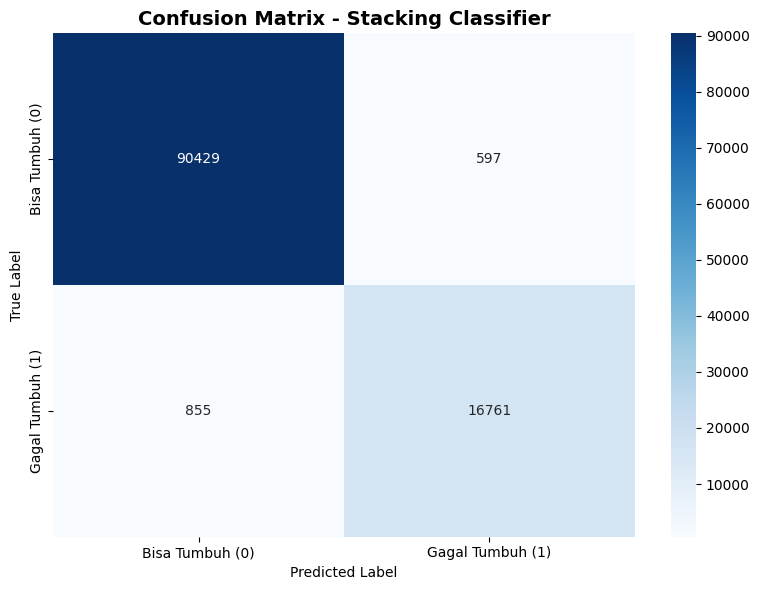

In [34]:
# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=['Bisa Tumbuh (0)', 'Gagal Tumbuh (1)'],
    yticklabels=['Bisa Tumbuh (0)', 'Gagal Tumbuh (1)']
)
plt.title('Confusion Matrix - Stacking Classifier', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

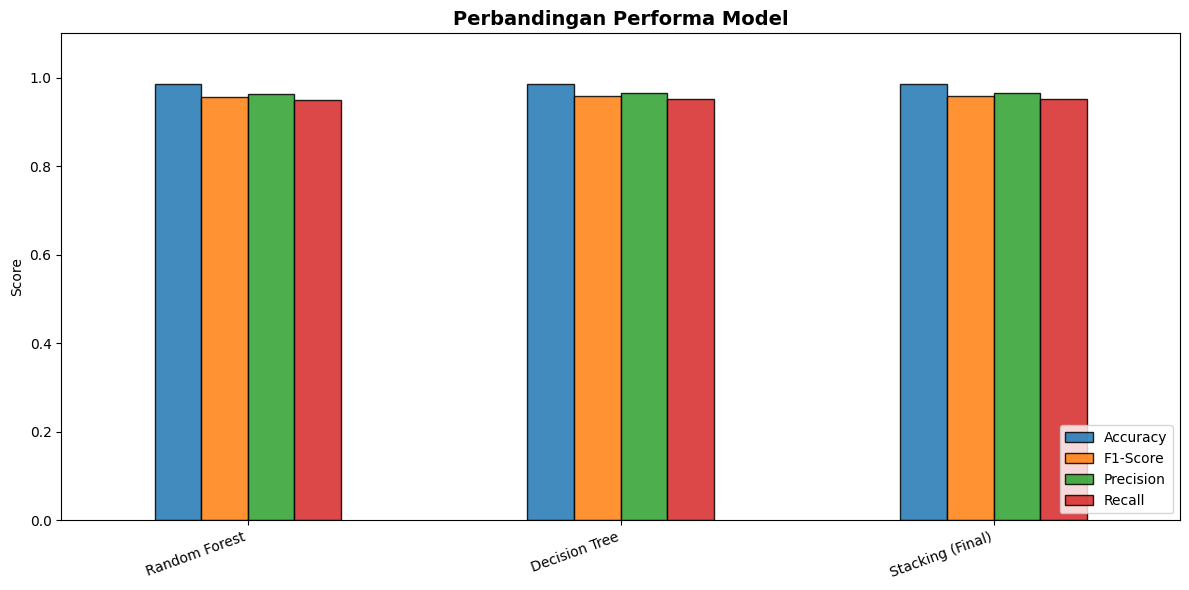

                  Accuracy  F1-Score  Precision  Recall
Random Forest       0.9857    0.9557     0.9619  0.9495
Decision Tree       0.9866    0.9585     0.9656  0.9515
Stacking (Final)    0.9866    0.9585     0.9656  0.9515


In [35]:
# Perbandingan semua model
all_results = {}
for name, info in results.items():
    y_p = info['model'].predict(X_test_preprocessed)
    all_results[name] = {
        'Accuracy': accuracy_score(y_test, y_p),
        'F1-Score': f1_score(y_test, y_p),
        'Precision': precision_score(y_test, y_p),
        'Recall': recall_score(y_test, y_p),
    }
all_results['Stacking (Final)'] = {
    'Accuracy': acc, 'F1-Score': f1, 'Precision': prec, 'Recall': rec
}

results_df = pd.DataFrame(all_results).T

results_df.plot(kind='bar', figsize=(12, 6), edgecolor='black', alpha=0.85)
plt.title('Perbandingan Performa Model', fontsize=14, fontweight='bold')
plt.ylabel('Score')
plt.xticks(rotation=20, ha='right')
plt.ylim(0, 1.1)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

print(results_df.round(4))

## 9. Simpan Model dan Preprocessor

Kita simpan dua file:
- `model.pkl` — model Stacking Classifier yang sudah dilatih
- `preprocessor.pkl` — pipeline preprocessing yang HARUS digunakan di backend

In [36]:
import joblib

# Simpan model utama
joblib.dump(model, '../model/model.pkl')

# Kalau masih pakai preprocessor terpisah (optional)
joblib.dump(preprocessor, '../model/preprocessor.pkl')

print('Model berhasil disimpan di ../model/model.pkl')
print('Preprocessor berhasil disimpan di ../model/preprocessor.pkl')

Model berhasil disimpan di ../model/model.pkl
Preprocessor berhasil disimpan di ../model/preprocessor.pkl


In [39]:
import joblib

loaded_model = joblib.load('../model/model.pkl')
loaded_prep  = joblib.load('../model/preprocessor.pkl')

sample = X_test.iloc[[0]]
sample_processed = loaded_prep.transform(sample)

sample_pred = loaded_model.predict(sample_processed)
sample_proba = loaded_model.predict_proba(sample_processed)[0]

print(f'Sample input:\n{sample.to_dict(orient="records")[0]}')
print(f'\nPrediksi: {"Gagal Tumbuh" if sample_pred[0] == 1 else "Bisa Tumbuh"}')
print(f'Probabilitas: Bisa Tumbuh={sample_proba[0]:.3f}, Gagal Tumbuh={sample_proba[1]:.3f}')
print('\nModel berhasil diverifikasi!')

Sample input:
{'soil_type': 'Sandy', 'bulk_density': 1.6, 'organic_matter_pct': 1.2, 'cation_exchange_capacity': 5, 'salinity_ec': 0.4, 'buffering_capacity': 0.3, 'soil_moisture_pct': 35.39, 'moisture_limit_dry': 8, 'moisture_limit_wet': 28, 'moisture_regime': 'waterlogged', 'soil_temp_c': 27.4, 'air_temp_c': 32.3, 'thermal_regime': 'optimal', 'light_intensity_par': 1003.0, 'soil_ph': 6.15, 'ph_stress_flag': 0, 'nitrogen_ppm': 86.5, 'phosphorus_ppm': 65.4, 'potassium_ppm': 92.1, 'nutrient_balance': 'deficient', 'plant_category': 'vegetable'}

Prediksi: Bisa Tumbuh
Probabilitas: Bisa Tumbuh=1.000, Gagal Tumbuh=0.000

Model berhasil diverifikasi!
